In [1]:
import torch                          # import torch library
import torch.nn as nn                 # import nn module for creating layers, models and functions
import numpy as np                    # import numpy library
import matplotlib.pyplot as plt       # import pyplot library
from torch.autograd import Variable   # variable from numpy to torch

seed = 27
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # set GPU as processing device
print(device)

cuda:0


In [3]:
epochs        = 6000    # number of training epochs
col_p         = 35      # number of collocation points
hidden_size   = 30      # number of neurons per hidden layer
learning_rate = 0.001   # learning rate parameter

E   = 21e9              # Pa  (Young Modulus)
I   = (.10*(.15**3)/12) # m^4 (Beam inertia)
L   = 3                 # m   (Beam length)
q_0 = 5000              # N/m (Punctual load q)

class NN(nn.Module):
    def __init__(self):
        super(NN, self).__init__()
        self.fc1 = nn.Linear(1, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.fc4 = nn.Linear(hidden_size, hidden_size)
        self.fc5 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        v = torch.tanh(self.fc1(x))
        v = torch.tanh(self.fc2(v))
        v = torch.tanh(self.fc3(v))
        v = torch.tanh(self.fc4(v))
        v = self.fc5(v)
        return v

In [4]:
### (2) Model
# Create the neural network and move it to the GPU if available
NN = NN().to(device)                                       # transfer net to GPU for processing
mse_cost_function = torch.nn.MSELoss()                     # mean squared error as loss function
optimizer = torch.optim.Adam(NN.parameters(), lr=learning_rate)  # Adam optimizer for parameter updating

In [5]:
## PDE as loss function.
def f(x,NN):
    v = NN(x) # the dependent variable u is given by the network based on independent variable x
    ## Based on our f = E*I*d4v/dx4 - (q_0/L)*x, we need d4v/dx4
    dvdx   = torch.autograd.grad(v.sum(),   x,create_graph=True)[0]    # dv/dx
    d2vdx2 = torch.autograd.grad(dvdx.sum(), x,create_graph=True)[0]   # d2v/dx2
    d3vdx3 = torch.autograd.grad(d2vdx2.sum(),x,create_graph=True)[0]  # d3v/dx3
    d4vdx4 = torch.autograd.grad(d3vdx3.sum(),x,create_graph=True)[0]  # d4v/dx4
    pde    = d4vdx4 + q_0/(E*I*L)*x                        
    return pde

In [6]:
## Data from Boundary Conditions
## BC gives us datapoints for training
## We will find out v(x) for x in range [0,L]

#################################### 1. x=0, v(0)=0 ####################################
x_bc1       = np.array([0.0])  # x value for the boundary condition
v_bc1       = np.array([0.0])  # v value for the boundary condition
pt_x_bc1    = Variable(torch.from_numpy(x_bc1).float(), requires_grad=True).to(device)
pt_v_bc1    = Variable(torch.from_numpy(v_bc1).float(), requires_grad=False).to(device)

#################################### 2. x=0, dv/dx=0 ###################################
x_bc2       = np.array([0.0])  # x value for the boundary condition
v_x_bc2     = np.array([0.0])  # dv/dx value for the boundary condition
pt_x_bc2    = Variable(torch.from_numpy(x_bc2).float(), requires_grad=True).to(device)
pt_v_x_bc2  = Variable(torch.from_numpy(v_x_bc2).float(), requires_grad=False).to(device)

#################################### 3. x=L, EI*d3v/dx3=0 ###############################
x_bc3       = np.array([L])    # x value for the boundary condition
v_x3_bc3    = np.array([0.0])  # d3v/dx3 value for the boundary condition
pt_x_bc3    = Variable(torch.from_numpy(x_bc3).float(), requires_grad=True).to(device)
pt_v_x3_bc3 = Variable(torch.from_numpy(v_x3_bc3).float(), requires_grad=False).to(device)

#################################### 4. x=L, EI*d2v/dx2=0 ##############################
x_bc4       = np.array([L])    # x value for the boundary condition
v_x2_bc4    = np.array([0.0])  # d2v/dx2 value for the boundary condition
pt_x_bc4    = Variable(torch.from_numpy(x_bc4).float(), requires_grad=True).to(device)
pt_v_x2_bc4 = Variable(torch.from_numpy(v_x2_bc4).float(), requires_grad=False).to(device)

In [1]:
### (3) Training / Fitting

Loss_bc1   = []
Loss_bc2   = [] 
Loss_bc3   = [] 
Loss_bc4   = [] 
Loss_f     = []
Loss_track = []                    # Initialize empty list for gathering loss values

NN.train()

for epoch in range(epochs):
    optimizer.zero_grad() # to make the gradients zero
    
    # Loss based on boundary conditions
    # BC 1.      
    NN_bc1_out = NN(pt_x_bc1) # output NN(x) --> v
    mse_u1     = mse_cost_function(NN_bc1_out, pt_v_bc1)
    
    # BC 2.  
    NN_bc2_out = NN(pt_x_bc2) # output NN(x) --> v
    dv_x_bc2   = torch.autograd.grad(NN_bc2_out.sum(),pt_x_bc2,create_graph=True)[0]
    mse_u2     = mse_cost_function(dv_x_bc2, pt_v_x_bc2)

    # BC 3.    
    NN_bc3_out = NN(pt_x_bc3) # output NN(x) --> v
    dv_x_bc3   = torch.autograd.grad(NN_bc3_out.sum(),pt_x_bc3,create_graph=True)[0]
    dv_x2_bc3  = torch.autograd.grad(dv_x_bc3.sum(),pt_x_bc3,create_graph=True)[0]
    dv_x3_bc3  = torch.autograd.grad(dv_x2_bc3.sum(),pt_x_bc3,create_graph=True)[0]
    mse_u3     = mse_cost_function(dv_x3_bc3, pt_v_x3_bc3)
        
    # BC 4.  
    NN_bc4_out = NN(pt_x_bc4) # output NN(x) --> v
    dv_x_bc4   = torch.autograd.grad(NN_bc4_out.sum(),pt_x_bc4,create_graph=True)[0]
    dv_x2_bc4  = torch.autograd.grad(dv_x_bc4.sum(),pt_x_bc4,create_graph=True)[0]
    mse_u4     = mse_cost_function(dv_x2_bc4, pt_v_x2_bc4)
    
    # Loss based on PDE
    x_col        = np.random.uniform(low=0.0, high=L, size=(col_p,1))
    pt_x_col     = Variable(torch.from_numpy(x_col).float(), requires_grad=True).to(device)
    all_zeros    = np.zeros((col_p,1))
    pt_all_zeros = Variable(torch.from_numpy(all_zeros).float(), requires_grad=False).to(device)
    
    f_out        = f(pt_x_col,NN)                 # Output of f(x)
    mse_f        = mse_cost_function(f_out, pt_all_zeros)
    
    # Combining the loss functions
    loss = mse_u1 + mse_u2 + mse_u3 + mse_u4 + mse_f
    
    loss.backward()  # This is for computing gradients using backward propagation
    optimizer.step() # This is equivalent to: theta_new = theta_old - alpha * derivative of J w.r.t theta
    
    loss_bc1 = mse_u1.data.cpu().numpy()
    loss_bc2 = mse_u2.data.cpu().numpy()
    loss_bc3 = mse_u3.data.cpu().numpy()
    loss_bc4 = mse_u4.data.cpu().numpy()
    loss_f   =  mse_f.data.cpu().numpy()
    loss_np  =   loss.data.cpu().numpy()          # Torch tensors to Numpy
    
    Loss_bc1   = np.append(Loss_bc1,   loss_bc1)
    Loss_bc2   = np.append(Loss_bc2,   loss_bc2)
    Loss_bc3   = np.append(Loss_bc3,   loss_bc3)
    Loss_bc4   = np.append(Loss_bc4,   loss_bc4)
    Loss_f     = np.append(Loss_f,     loss_f)
    Loss_track = np.append(Loss_track, loss_np)   # Tracking loss values and creating a list
    
    with torch.autograd.no_grad():
        if epoch % 100 == 0: print(epoch,"Traning Loss:",loss.data) # Print loss every 10 epochs

NameError: name 'NN' is not defined

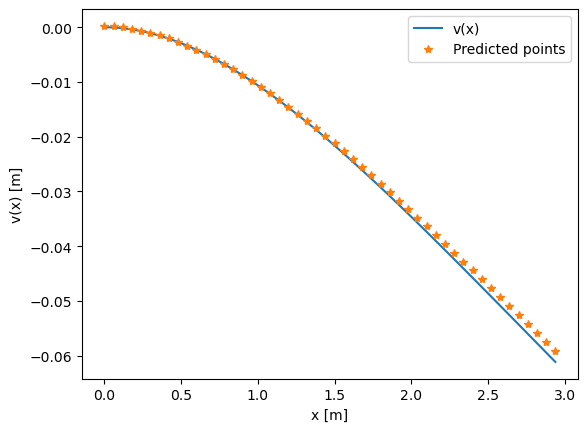

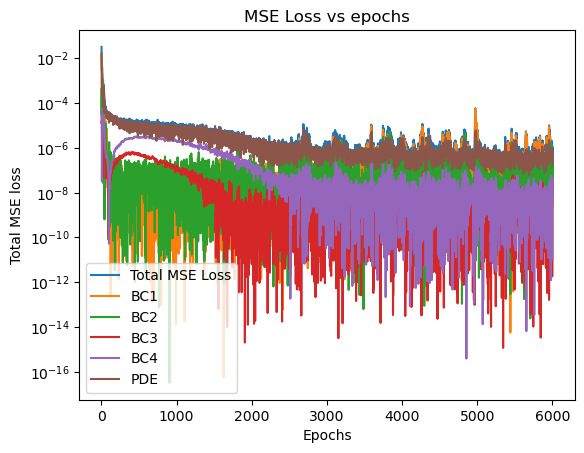

In [8]:
#### Plotting results ###

# Differential equation vs Predicted results
x = np.arange(0,L,0.06)
v = -q_0*(x**5)/(120*E*I*L)+q_0*L*(x**3)/(12*E*I)-q_0*(L**2)*(x**2)/(6*E*I)

x_test    = x.reshape(-1,1)
pt_x      = Variable(torch.from_numpy(x_test).float(), requires_grad=True).to(device)
pt_v_pred = NN(pt_x)
v_pred    = pt_v_pred.data.cpu().numpy()

plt.plot(x,v)
plt.plot(x,v_pred,'*')
plt.xlabel('x [m]')
plt.ylabel('v(x) [m]')
plt.legend(['v(x)','Predicted points'])
plt.show()

#Loss graphics
ep = np.linspace(1,epochs,epochs)
plt.semilogy(ep,Loss_track)
plt.title('MSE Loss vs epochs')
plt.xlabel('Epochs')
plt.ylabel('Total MSE loss')

plt.semilogy(ep,Loss_bc1)
plt.semilogy(ep,Loss_bc2)
plt.semilogy(ep,Loss_bc3)
plt.semilogy(ep,Loss_bc4)
plt.semilogy(ep,Loss_f)

plt.legend(['Total MSE Loss','BC1','BC2','BC3','BC4','PDE'])
plt.show()